# Supplier Selection & Dynamic Volume Allocation — walkthrough

Interactive walkthrough of the MILP solver in `src/solver.py`. See
`README.md` for the project overview and `docs/methodology.md` for the
full mathematical formulation.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.solver import ProcurementProblem, solve_procurement, solve_manual_baseline
from src.simulation import run_feasible_solution_sweep

## 1. Load data

Uses the real procurement dataset committed at `data/procurement_data.xlsx`. Point `xls` at a different workbook if needed (see README for the required schema).

In [2]:
xls = pd.ExcelFile("../data/procurement_data.xlsx")
vendor_df = pd.read_excel(xls, "vendor_list")
product_df = pd.read_excel(xls, "product_list")
bom_df = pd.read_excel(xls, "BOM")
quotation_df = pd.read_excel(xls, "quotation")

vendor_df.head()

,vendor_id,vendor_name,category,oversea_vendor,Lead time
0,VN-VD01,BioTech Global Solutions Ltd.,reagent,1,35
1,VN-VD02,GeneSys Lab Equipment Corp.,reagent,0,24
2,VN-VD03,MediCore Diagnostics Asia,reagent,1,40
3,VN-VD04,Nexus Life Science Co.,normal chemical,1,45
4,VN-VD05,Apex Pharma Logistics,normal chemical,0,21


In [3]:
problem = ProcurementProblem.from_raw_sheets(
    vendor_df=vendor_df,
    product_df=product_df,
    bom_df=bom_df,
    quotation_df=quotation_df,
    bom_tolerance=0.08,
    price_weight=0.4,
    lead_time_weight=0.6,
)
problem.prepared_quotation.head()

,product_id,vendor_id,quantity,unit_price,MOQ,Capacity,lead_time,oversea_vendor,po_cost,p_norm,lt_norm,risk_coeff
0,VN-MT001,VN-VD18,1598,1.55,1500,4000,24,1,100.0,0.0,0.400000,0.240000
1,VN-MT001,VN-VD21,1598,1.70,500,1500,10,0,50.0,1.0,0.000000,0.400000
2,VN-MT002,VN-VD17,652,3.00,800,5000,14,0,50.0,0.0,0.114286,0.068571
3,VN-MT002,VN-VD22,652,3.20,200,1000,14,0,50.0,1.0,0.114286,0.468571
4,VN-MT003,VN-VD16,1489,1.80,200,1000,24,1,100.0,0.0,0.400000,0.240000


## 2. Solve the cost-optimal model

In [4]:
result_cost = solve_procurement(problem, objective_type="cost")

print(f"Status: {result_cost.status}")
print(f"Total cost: ${result_cost.total_cost:,.2f}")
print(f"Vendors used: {result_cost.n_vendors_used}/{result_cost.n_vendors_available}")
result_cost.allocation.head()

Status: OPTIMAL
Total cost: $678,481.24
Vendors used: 22/23


,product_id,vendor_id,allocated_quantity,unit_price,lead_time,total_cost,risk_contribution
0,VN-MT001,VN-VD18,1598.0,1.55,24,2476.90,383.520000
1,VN-MT002,VN-VD22,652.0,3.20,14,2086.40,305.508571
2,VN-MT003,VN-VD16,1000.0,1.80,24,1800.00,240.000000
3,VN-MT003,VN-VD22,489.0,2.15,14,1051.35,229.131429
4,VN-MT004,VN-VD19,1422.0,1.00,24,1422.00,341.280000


## 3. Solve the risk-balanced model, with and without the relationship constraint

In [5]:
result_risk = solve_procurement(problem, objective_type="risk", require_all_vendors=False)
result_risk_all = solve_procurement(problem, objective_type="risk", require_all_vendors=True)

pd.DataFrame([
    {"model": "cost", **vars(result_cost)},
    {"model": "risk", **vars(result_risk)},
    {"model": "risk_all_vendors", **vars(result_risk_all)},
])[["model", "total_cost", "total_risk", "n_vendors_used", "n_vendors_available"]]

,model,total_cost,total_risk,n_vendors_used,n_vendors_available
0,cost,678481.24,6408.034303,22,23
1,risk,680446.34,6290.679065,22,23
2,risk_all_vendors,680586.34,6313.536207,23,23


## 4. Benchmark against a manual (greedy, cheapest-first) baseline

In [6]:
_, manual_cost = solve_manual_baseline(problem)
savings = manual_cost - result_cost.total_cost
savings_pct = savings / manual_cost * 100

print(f"Manual baseline cost:  ${manual_cost:,.2f}")
print(f"MILP-optimal cost:     ${result_cost.total_cost:,.2f}")
print(f"Savings:               ${savings:,.2f} ({savings_pct:.2f}%)")

Manual baseline cost:  $678,592.07
MILP-optimal cost:     $678,481.24
Savings:               $110.83 (0.02%)


## 5. Prove optimality: 100 random feasible plans vs. the MILP optimum

MILP solvers are provably optimal, so this cell isn't a correctness check —
it's a way to make the value of optimization visually obvious to a
non-technical audience. Every plotted point is a genuinely feasible
purchase plan; none of them beat the dashed line.

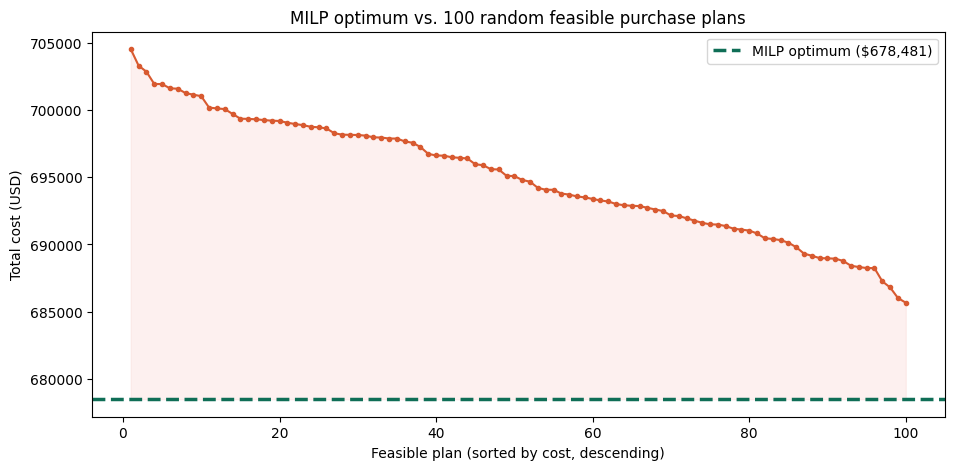

In [7]:
import matplotlib.pyplot as plt

feasible_costs = run_feasible_solution_sweep(problem, n_simulations=100)

plt.figure(figsize=(11, 5))
plt.plot(range(1, len(feasible_costs) + 1), feasible_costs, color="#D85A30", marker="o", markersize=3)
plt.axhline(y=result_cost.total_cost, color="#0F6E56", linestyle="--", linewidth=2.5,
            label=f"MILP optimum (${result_cost.total_cost:,.0f})")
plt.fill_between(range(1, len(feasible_costs) + 1), feasible_costs, result_cost.total_cost,
                  color="#FADBD8", alpha=0.4)
plt.title("MILP optimum vs. 100 random feasible purchase plans")
plt.xlabel("Feasible plan (sorted by cost, descending)")
plt.ylabel("Total cost (USD)")
plt.legend()
plt.show()